In [1]:
import numpy as np
import pandas as pd

class AvellanedaStoikov:
    def __init__(self, gamma, kappa):
        self.gamma=gamma
        self.kappa=kappa
        
    def reservation_price(self, s, q, sigma, T_t):
        return s-q*self.gamma*(sigma**2)*T_t
        
    def optimal_spread(self, sigma, T_t):
        inv_term= self.gamma* (sigma**2)*T_t
        book_term=(2/self.gamma)*np.log(1+self.gamma/ self.kappa)
        return inv_term+book_term
        
    def quotes(self, s, q, sigma, T_t):
        r=self.reservation_price(s,q,sigma,T_t)
        delta=self.optimal_spread(sigma, T_t)
        bid=r-delta/2
        ask=r+delta/2
        return bid, ask, r, delta

model=AvellanedaStoikov(gamma=0.1,kappa=1.5)
bid, ask, r, delta=model.quotes(s=100, q=5, sigma=0.1, T_t=0.8)
print(model)
print(f"Reservation price: {r:.4f}")
print(f"Optimal spread   : {delta:.4f}")
print(f"Bid              : {bid:.4f}")
print(f"Ask              : {ask:.4f}")

print(f"r below mid? {r<100}")

print(f"ask-r :{(ask-r):.4f}")
print(f"r-bid :{(r-bid):.4f}")
print(f"both equal? : {abs((ask-r)-(r-bid)) < 0.0001}")

bid0, ask0,r0,delta0=model.quotes(s=100, q=0, sigma=0.1, T_t=0.8)
print(f"r when q=0 : {r0:.4f}")
print(f"r equals mid?: {abs(r0-100)<0.0001}")







Reservation price: 99.9960
Optimal spread   : 1.2916
Bid              : 99.3502
Ask              : 100.6418
r below mid? True
ask-r :0.6458
r-bid :0.6458
both equal? : True
r when q=0 : 100.0000
r equals mid?: True
100


In [2]:
import numpy as np
class MarketSimulater:
    def __init__(self,s0,sigma,dt=1):
        self.price=s0
        self.sigma=sigma
        self.dt=dt
        
       
    def next_price(self):
        shock=self.sigma*np.sqrt(self.dt)*np.random.normal()
        self.price+=shock
        return self.price
    def fill_check(self, bid, ask):
        spread=ask-bid
        half=spread/2
        bid_dist=max(self.price-bid, 0)
        ask_dist=max(ask-self.price, 0)
        bid_prob=0.5*np.exp(-bid_dist/(half+1e-8))
        ask_prob=0.5*np.exp(-ask_dist/(half+1e-8))
        bid_filled=np.random.random()<bid_prob
        ask_filled=np.random.random()<ask_prob
        return bid_filled, ask_filled
       
    
    
        

market=MarketSimulater(s0=100, sigma=0.01)
print(market.price)
for i in range(5):
    print(f"step {i+1}: {market.next_price():.4f}")

bid_filled, ask_filled=market.fill_check(bid=99.35, ask=100.64)
print(f"bid filled: {bid_filled}")
print(f"ask filled: {ask_filled}")


100
step 1: 100.0078
step 2: 100.0074
step 3: 100.0035
step 4: 100.0176
step 5: 100.0139
bid filled: False
ask filled: True


In [3]:
class Portfolio:
    def __init__(self, cash=10000):
        self.cash=cash
        self.inventory=0
        self.trades=[]
        
    def buy(self, price, qty=1):
        self.cash-=price*qty
        self.inventory+=qty
        self.trades.append(("buy",price,qty))
    def sell(self, price, qty=1):
        self.cash+=price*qty
        self.inventory-=qty
        self.trades.append(("sell", price, qty))
    def total_wealth(self, current_price):
        return self.cash+(self.inventory*current_price)
    def summary(self, current_price):
        print(f"cash: {self.cash:.4f}")
        print(f"Inventory: {self.inventory}")
        print(f"Total Wealth: {self.total_wealth(current_price):.4f}")
        print(f"Total trades: {len(self.trades)}")
        
portfolio=Portfolio(cash=10000)

portfolio.buy(price=99.35)
portfolio.buy(price=99.20)
portfolio.sell(price=100.64)

portfolio.summary(current_price=100)



cash: 9902.0900
Inventory: 1
Total Wealth: 10002.0900
Total trades: 3


In [4]:
def backtest(n_steps=1000, gamma=0.1, kappa=1.5, sigma=0.01):
    model=AvellanedaStoikov(gamma=gamma, kappa=kappa)
    market=MarketSimulater(s0=100, sigma=sigma)
    portfolio=Portfolio(cash=10000)
    history=[]
    for t in range(n_steps):
        s=market.next_price()
        q=portfolio.inventory
        T_t=max(1-t/n_steps, 0.05)
        bid, ask, r, delta=model.quotes(s, q, sigma=market.sigma, T_t=T_t)
        bid_filled, ask_filled=market.fill_check(bid, ask)
        if bid_filled and portfolio.inventory>-10:
            portfolio.buy(bid)
        if ask_filled and portfolio.inventory<10:
            portfolio.sell(ask)
            
        history.append({
                "step":t,
                "price":s,
                "bid":bid,
                "ask":ask,
                "r":r,
                "inventory":portfolio.inventory,
                "wealth":portfolio.total_wealth(s)
        })
    return history
np.random.seed(42)
history=backtest(n_steps=1000, gamma=1.5,)
for row in history[:5]:
    print(row)

print(f"\nFinal wealth: {history[-1]["wealth"]:.4f}")
print(f"Total trades: {len([r for r in history if r["inventory"]!=(history[history.index(r)-1]["inventory"] if history.index(r)>0 else 0)])}")
            

{'step': 0, 'price': 100.00496714153012, 'bid': 99.54279402115682, 'ask': 100.46714026190341, 'r': 100.00496714153012, 'inventory': 0, 'wealth': 10000.0}
{'step': 1, 'price': 100.0035844985184, 'bid': 99.54141145314512, 'ask': 100.4657575438917, 'r': 100.0035844985184, 'inventory': 0, 'wealth': 10000.924346090747}
{'step': 2, 'price': 100.01937662667348, 'bid': 99.55720365630017, 'ask': 100.48154959704678, 'r': 100.01937662667348, 'inventory': 1, 'wealth': 10001.38651906112}
{'step': 3, 'price': 100.027050973965, 'bid': 99.5647285285917, 'ask': 100.4890743193383, 'r': 100.026901423965, 'inventory': 1, 'wealth': 10001.394193408412}
{'step': 4, 'price': 100.02241679703688, 'bid': 99.56009457666359, 'ask': 100.48444021741018, 'r': 100.02226739703688, 'inventory': 1, 'wealth': 10001.389559231484}

Final wealth: 10160.9407
Total trades: 228


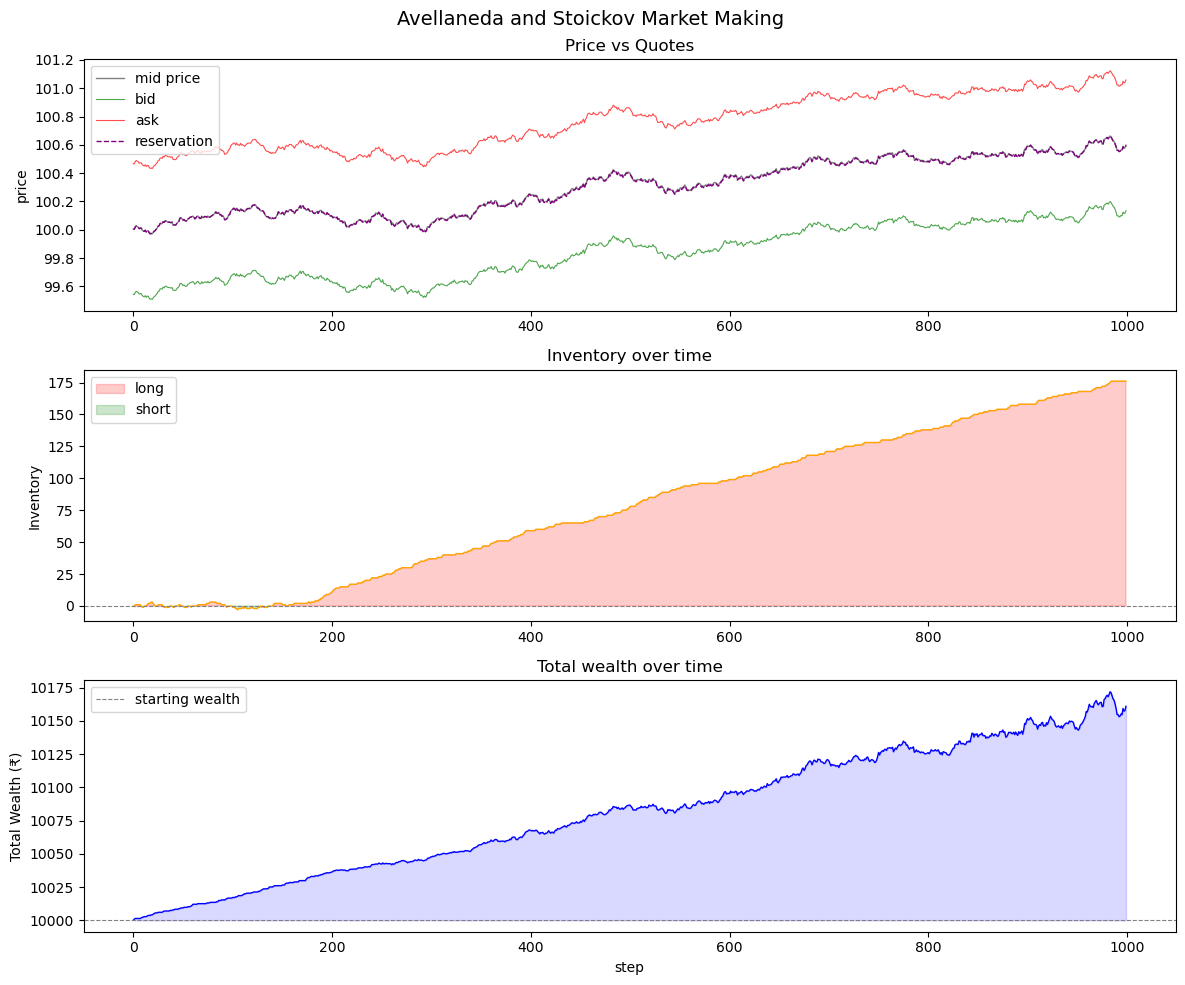

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

df=pd.DataFrame(history)

fig, axes=plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle("Avellaneda and Stoickov Market Making", fontsize=14)

axes[0].plot(df["step"], df["price"], color="gray", label="mid price", linewidth=1)
axes[0].plot(df["step"], df["bid"], color="green", label="bid", linewidth=0.8, alpha=0.7)
axes[0].plot(df["step"], df["ask"], color="red", label="ask", linewidth=0.8, alpha=0.7)
axes[0].plot(df["step"], df["r"], color="purple", label="reservation", linewidth=1, linestyle="--")
axes[0].set_ylabel("price")
axes[0].legend(loc="upper left")
axes[0].set_title("Price vs Quotes")

axes[1].plot(df["step"], df["inventory"], color="orange", linewidth=1)
axes[1].axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
axes[1].fill_between(df["step"], df["inventory"], 0,
                     where=(df["inventory"]>0), color="red", alpha=0.2, label="long")
axes[1].fill_between(df["step"], df["inventory"],0,
                     where=(df["inventory"]<0), color="green", alpha=0.2 , label="short")
axes[1].set_ylabel("Inventory")
axes[1].legend(loc="upper left")
axes[1].set_title("Inventory over time")

axes[2].plot(df["step"], df["wealth"], color="blue", linewidth=1)
axes[2].axhline(y=10000, color="gray", linestyle="--", linewidth=0.8, label="starting wealth")
axes[2].fill_between(df["step"], df["wealth"], 10000,
                     where=(df["wealth"]>10000), color="blue", alpha=0.15)
axes[2].set_ylabel("Total Wealth (₹)")
axes[2].set_xlabel("step")
axes[2].legend(loc="upper left")
axes[2].set_title("Total wealth over time")

plt.tight_layout()
plt.show()